# **Initial Setup & Data Loading**

In [1]:
# Step 1.1: Import Libraries (Final Version)

# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- Scikit-learn for Preprocessing and Modeling ---
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# --- Machine Learning Models (Our Final Gauntlet) ---
# 1. Linear Model
from sklearn.linear_model import LogisticRegression
# 2. Distance-based
from sklearn.neighbors import KNeighborsClassifier
# 3. Probabilistic
from sklearn.naive_bayes import GaussianNB
# 4. Bagging Ensemble
from sklearn.ensemble import RandomForestClassifier
# 5. Boosting Ensembles
from sklearn.ensemble import AdaBoostClassifier # Added as per our discussion
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

print("✅ All libraries imported successfully for the final, comprehensive model gauntlet.")

✅ All libraries imported successfully for the final, comprehensive model gauntlet.


In [2]:
# Step 1.2: Global Configuration & Settings

# --- Notebook Settings ---
# Suppress warnings to keep the notebook output clean and readable
warnings.filterwarnings('ignore')
# Set a professional and aesthetically pleasing style for all our plots
sns.set_style("whitegrid")
# Set a default figure size for all plots to ensure consistency
plt.rcParams['figure.figsize'] = (12, 6)

# --- Global Constants ---
# Our single source of truth for all randomness in this project.
# This ensures that any step with a random component (like model training
# or data splitting) can be perfectly reproduced.
RANDOM_SEED = 42

# Define our robust cross-validation strategy. We define it once here
# so we can use it consistently throughout the notebook for all model evaluations.
CV_STRATEGY = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_SEED
)

print(f"✅ Global configuration set.")
print(f"RANDOM_SEED is locked to: {RANDOM_SEED}")
print(f"Cross-validation strategy is defined.")

✅ Global configuration set.
RANDOM_SEED is locked to: 42
Cross-validation strategy is defined.


In [3]:
# Step 1.3: Data Loading

# In Kaggle notebooks, the competition data is located in the /kaggle/input/ directory.
# The specific folder name is usually the URL slug of the competition.
COMPETITION_NAME = 'playground-series-s5e11'
BASE_PATH = f'/kaggle/input/{COMPETITION_NAME}/'

try:
    # Use the defined path to load the datasets into pandas DataFrames
    train_df = pd.read_csv(BASE_PATH + 'train.csv')
    test_df = pd.read_csv(BASE_PATH + 'test.csv')
    sample_submission_df = pd.read_csv(BASE_PATH + 'sample_submission.csv')

    print("✅ Data loaded successfully!")
    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")
    print(f"Submission sample shape: {sample_submission_df.shape}")

except FileNotFoundError as e:
    print(f"❌ ERROR: Data files not found. Please check the competition folder name.")
    print(f"We tried to load from this path: {BASE_PATH}")
    print("Please verify the folder name in the /kaggle/input/ directory on the right sidebar.")
    print(f"Original error: {e}")

✅ Data loaded successfully!
Training data shape: (593994, 13)
Test data shape: (254569, 12)
Submission sample shape: (254569, 2)


In [4]:
# ===================================================================
# Step 1.4: Initial Data Preview
# ===================================================================

# Check if the train_df DataFrame was loaded before trying to display it
if 'train_df' in locals():
    print("\n--- Training Data Head ---")
    # The 'id' column is just an identifier and not useful for modeling,
    # so we'll drop it from the start. We do this for both train and test sets.
    train_df = train_df.drop('id', axis=1)
    test_df = test_df.drop('id', axis=1)
    print("Dropped 'id' column from train and test sets.")
    display(train_df.head())

    print("\n--- Test Data Head ---")
    display(test_df.head())

    print("\n--- Sample Submission Head ---")
    display(sample_submission_df.head())
else:
    print("❌ DataFrames not loaded. Please fix the loading step in Cell 3.")


--- Training Data Head ---
Dropped 'id' column from train and test sets.


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0



--- Test Data Head ---


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1



--- Sample Submission Head ---


,id,loan_paid_back
0,593994,0
1,593995,0
2,593996,0
3,593997,0
4,593998,0


# **Comprehensive EDA & ydata-profiling**

In [5]:
# Step 2.1: Install ydata-profiling

# ydata-profiling is not always pre-installed in Kaggle environments.
# We use !pip to install it. The -q flag stands for "quiet".
!pip install ydata-profiling -q

print("✅ ydata-profiling installed successfully.")

✅ ydata-profiling installed successfully.


In [6]:
# Step 2.2: Generate Comprehensive EDA Report

from ydata_profiling import ProfileReport

# Create a sample of the training data to speed up the report generation.
# A 10% sample is usually sufficient for initial EDA.
# We use random_state to ensure the sample is the same every time we run the notebook.
sample_df = train_df.sample(frac=0.1, random_state=RANDOM_SEED)

print(f"Creating EDA report on a sample of {len(sample_df)} rows...")

# Generate the report
# The title will appear at the top of the interactive report.
profile = ProfileReport(
    sample_df,
    title="Loan Payback Data - Initial EDA Report"
)

# Display the report directly in the notebook output.
# This will generate a rich, interactive HTML report.
profile

Creating EDA report on a sample of 59399 rows...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 14.53it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
# ===================================================================
# Step 2.3: Analyze Target Variable Distribution (Simple Version)
# ===================================================================

# Set the target column name to a variable for easy reuse
TARGET = 'loan_paid_back'

print(f"--- Analyzing Target Variable: '{TARGET}' ---")

# Use value_counts() with normalize=True to get the percentage distribution.
# This is the most direct way to see the class balance.
target_distribution = train_df[TARGET].value_counts(normalize=True) * 100

print("\nLoan Payback Rate Distribution (%):")
print(target_distribution)

# A simple interpretation based on the numbers
if abs(target_distribution[0] - target_distribution[1]) > 20:
    print("\n⚠️ WARNING: The dataset appears to be imbalanced. We must focus on AUC-ROC, not accuracy.")
else:
    print("\n✅ The dataset is reasonably balanced.")

--- Analyzing Target Variable: 'loan_paid_back' ---

Loan Payback Rate Distribution (%):
loan_paid_back
1.0    79.881952
0.0    20.118048
Name: proportion, dtype: float64

⚠️ WARNING: The dataset appears to be imbalanced. We must focus on AUC-ROC, not accuracy.


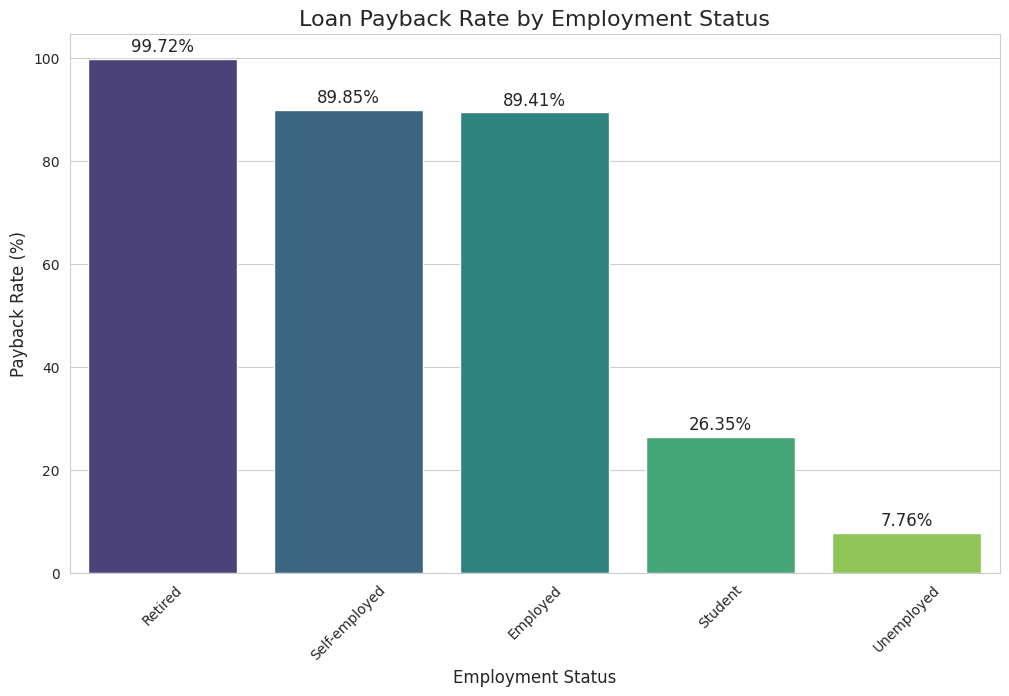

In [8]:
# Plot 1: employment_status vs. loan_paid_back

plt.figure(figsize=(12, 7))

# We use groupby to calculate the mean of 'loan_paid_back' for each category.
# Since 'loan_paid_back' is 0 or 1, the mean is the same as the payback rate.
payback_rates = train_df.groupby('employment_status')[TARGET].mean().sort_values(ascending=False) * 100

# Create the bar plot
ax = sns.barplot(x=payback_rates.index, y=payback_rates.values, palette='viridis')

plt.title('Loan Payback Rate by Employment Status', fontsize=16)
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Payback Rate (%)', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for better readability

# Add percentage annotations to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12)

plt.show()

--- Investigating 'credit_score' vs. 'interest_rate' ---


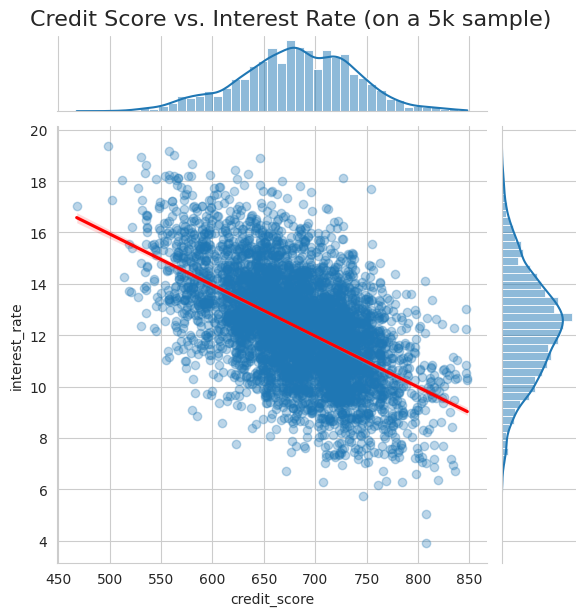

In [9]:
#Plot 2: credit_score vs. interest_rate

print("--- Investigating 'credit_score' vs. 'interest_rate' ---")

# A jointplot is a powerful tool that combines a scatter plot with histograms
# on the axes, giving a complete view of the two variables' relationship.
# We use a sample of 5,000 points to keep the plot clean and prevent overplotting.
# 'kind='reg'' adds a regression line, which makes the negative trend obvious.
g = sns.jointplot(
    data=train_df.sample(n=5000, random_state=RANDOM_SEED),
    x='credit_score',
    y='interest_rate',
    kind='reg', # Adds a regression line and a confidence interval
    joint_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3}} # Make line red, points transparent
)

g.fig.suptitle('Credit Score vs. Interest Rate (on a 5k sample)', y=1.02, fontsize=16)

plt.show()

# --- Interpretation ---
# We expect to see a clear negative correlation: as credit_score goes up,
# interest_rate should go down. This plot will show us how strong and
# consistent that relationship is.

--- Generating Correlation Matrix for Numerical Features ---


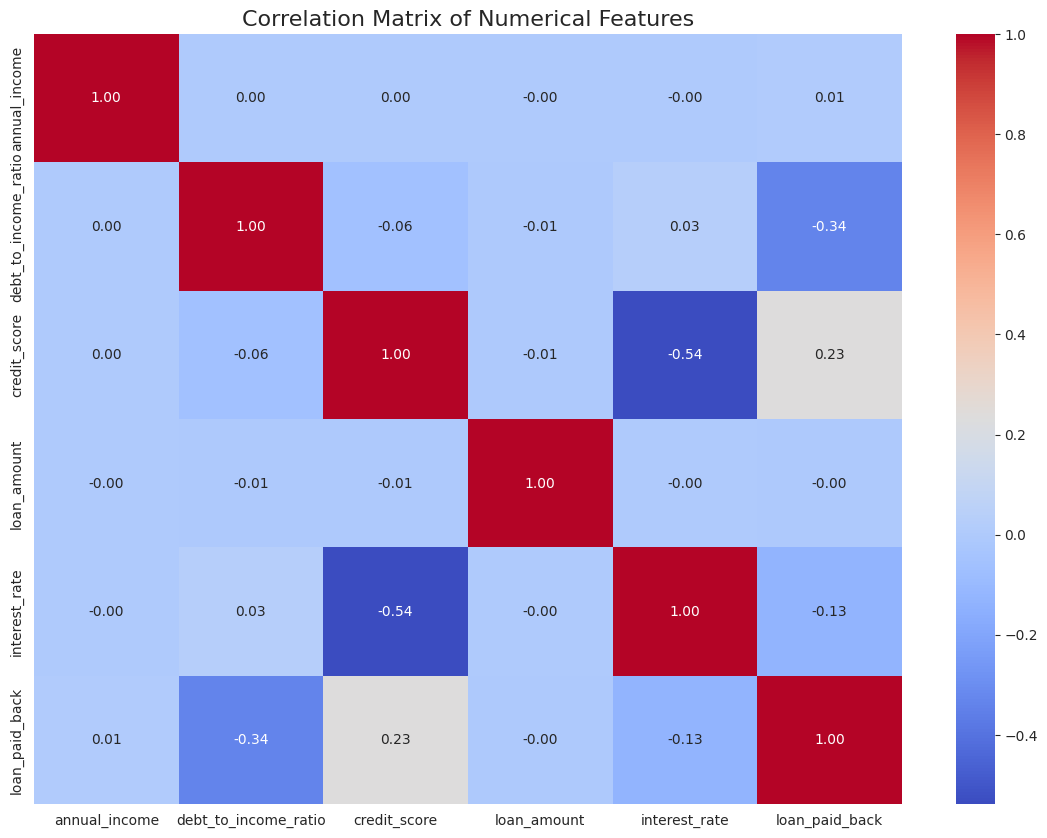

In [10]:
# Plot 3: Correlation of all numerical features

print("--- Generating Correlation Matrix for Numerical Features ---")

# First, we select only the columns with numerical data types.
numerical_cols = train_df.select_dtypes(include=np.number).columns

# Then, we calculate the Pearson correlation coefficient between each pair of these columns.
correlation_matrix = train_df[numerical_cols].corr()

# Now, we create the heatmap visualization.
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,      # This displays the correlation values on the heatmap squares.
    cmap='coolwarm', # This color map is great for correlations: blue is positive, red is negative.
    fmt=".2f"        # This formats the annotation numbers to two decimal places for readability.
)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

# --- Interpretation ---
# We will pay close attention to the last row/column, which corresponds to our
# target variable, 'loan_paid_back'. The values in this row tell us the
# linear correlation of each numerical feature with the likelihood of a loan being paid back.
# Values close to +1 or -1 indicate a strong linear relationship.
# Values close to 0 indicate a weak linear relationship.

In [11]:
# Code-Based Check for Other Categorical Features

# List of the other categorical features we are curious about.
# We already visualized 'employment_status', so we don't need to include it here.
categorical_features_to_check = ['gender', 'marital_status', 'education_level', 'loan_purpose', 'grade_subgrade']

print("--- Average Payback Rate (%) by Category ---")

for col in categorical_features_to_check:
    # We group by the feature's categories and calculate the mean of the target variable.
    # This gives us the payback rate for each group. We sort the results to easily
    # see the best and worst performing categories.
    payback_rate_by_cat = train_df.groupby(col)[TARGET].mean().sort_values(ascending=False)

    print(f"\n\n--- By '{col}' ---")
    # We multiply by 100 to display the result as a percentage.
    # Using .to_string() helps ensure the full list is printed, especially for 'grade_subgrade'.
    print((payback_rate_by_cat * 100).to_string())

# --- Interpretation ---
# We are looking for features where there is a large difference between the
# highest and lowest payback rates.
# A feature like 'gender' might have very similar rates for Male and Female,
# indicating it's not a strong predictor.
# A feature like 'grade_subgrade' should have a very clear trend, with 'A' grades
# having a much higher payback rate than 'G' grades.

--- Average Payback Rate (%) by Category ---


--- By 'gender' ---
gender
Female    80.170817
Male      79.575207
Other     79.533262


--- By 'marital_status' ---
marital_status
Married     79.914442
Single      79.887344
Divorced    79.664039
Widowed     78.984848


--- By 'education_level' ---
education_level
PhD            83.006714
High School    80.969759
Other          80.278892
Master's       80.234594
Bachelor's     78.889223


--- By 'loan_purpose' ---
loan_purpose
Home                  82.322408
Business              81.310370
Other                 80.237655
Car                   80.062986
Debt consolidation    79.691095
Vacation              79.607054
Medical               77.808471
Education             77.705303


--- By 'grade_subgrade' ---
grade_subgrade
A4    95.708407
A3    95.546951
A2    95.292369
A1    95.250000
A5    94.496155
B3    94.004021
B2    93.742995
B5    93.420392
B4    93.175758
B1    91.634133
C1    86.009032
C2    85.116544
C5    84.625917
C4    84.39

In [12]:
train_df.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


# **Essential Data Cleaning & Preprocessing**

In [13]:
# Identify Feature Types

print("--- Separating features into categorical and numerical lists ---")

# The target variable is not a feature, so we define it first.
TARGET = 'loan_paid_back'

# Identify categorical features: These are the columns with 'object' data type.
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# Identify numerical features: These are all columns that are not the target and not categorical.
numerical_features = [
    col for col in train_df.columns
    if col not in categorical_features and col != TARGET
]

# --- Verification ---
print(f"\nIdentified {len(categorical_features)} categorical features:")
print(categorical_features)

print(f"\nIdentified {len(numerical_features)} numerical features:")
print(numerical_features)

print(f"\nTarget variable is: '{TARGET}'")

--- Separating features into categorical and numerical lists ---

Identified 6 categorical features:
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Identified 5 numerical features:
['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

Target variable is: 'loan_paid_back'


# **Adversarial Validation**

In [14]:
# Prepare Data for Adversarial Validation

print("--- Preparing data for adversarial validation ---")

# We will use the encoded dataframes we would have created, but since we
# decided to do encoding in the pipeline, we need to create them temporarily here.
# This is a local, temporary step ONLY for this validation.

# --- Temporary Encoding (for this step only) ---
adv_train_df = train_df.copy()
adv_test_df = test_df.copy()

for col in categorical_features:
    le = LabelEncoder()
    combined_data = pd.concat([adv_train_df[col], adv_test_df[col]], axis=0)
    le.fit(combined_data)
    adv_train_df[col] = le.transform(adv_train_df[col])
    adv_test_df[col] = le.transform(adv_test_df[col])

# --- Create the Adversarial Dataset ---

# Create a new target variable. 0 for training data, 1 for test data.
adv_train_df['is_test'] = 0
adv_test_df['is_test'] = 1

# Combine the two dataframes. We drop the original target from the training data
# as it's not relevant for this validation.
adversarial_df = pd.concat([
    adv_train_df.drop(columns=[TARGET]),
    adv_test_df
], ignore_index=True)

# Shuffle the combined dataframe to mix the train and test rows.
adversarial_df = adversarial_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# --- Verification ---
print(f"Adversarial dataset created with shape: {adversarial_df.shape}")
print("New target variable 'is_test' distribution:")
print(adversarial_df['is_test'].value_counts(normalize=True))

display(adversarial_df.head())

--- Preparing data for adversarial validation ---
Adversarial dataset created with shape: (848563, 12)
New target variable 'is_test' distribution:
is_test
0    0.7
1    0.3
Name: proportion, dtype: float64


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,is_test
0,61939.55,0.097,665,26424.06,12.31,0,1,0,0,0,15,0
1,20462.01,0.139,550,11751.99,15.98,1,2,2,0,4,26,0
2,11676.01,0.066,772,13361.73,10.74,1,2,0,0,2,5,0
3,56465.18,0.157,775,14378.51,10.09,1,1,0,0,6,5,0
4,47916.05,0.204,726,7895.02,13.60,0,0,1,2,2,10,0


In [15]:
# Train the Adversarial Validation Model

print("--- Training adversarial validation model ---")

# Define the features (X) and the new target (y) for this validation task
X_adv = adversarial_df.drop(columns=['is_test'])
y_adv = adversarial_df['is_test']

# Initialize a simple LightGBM classifier. We don't need to tune it;
# we just need a quick and powerful model.
adv_model = LGBMClassifier(random_state=RANDOM_SEED)

# Use cross_val_score to get the AUC scores from our repeated k-fold strategy.
# This is a robust way to measure the model's performance.
# We use 'roc_auc' as the scoring metric.
cv_scores = cross_val_score(
    estimator=adv_model,
    X=X_adv,
    y=y_adv,
    cv=CV_STRATEGY,
    scoring='roc_auc',
    n_jobs=-1  # Use all available CPU cores to speed up the process
)

# Calculate the mean and standard deviation of the scores
mean_auc = np.mean(cv_scores)
std_auc = np.std(cv_scores)

print(f"\nAdversarial Validation Results ({CV_STRATEGY.get_n_splits()}-fold CV):")
print(f"Mean AUC: {mean_auc:.4f}")
print(f"Std Dev of AUC: {std_auc:.4f}")

# --- Interpretation ---
# This is the most important part. We need to interpret the Mean AUC score.
#
# - If AUC is ~0.50: This is PERFECT. It means the model is no better than random guessing.
#   This tells us the train and test sets are statistically identical. There is NO drift.
#
# - If AUC is between 0.51 and 0.60: This is GOOD. There might be very minor differences,
#   but they are not significant enough to worry about. Our CV scores should be reliable.
#
# - If AUC is between 0.60 and 0.70: This is a WARNING. There are noticeable differences
#   between the train and test sets. Our local CV scores might be slightly different from
#   the leaderboard score, but it's likely manageable.
#
# - If AUC is > 0.70: This is a RED ALERT. There is a significant difference (data drift)
#   between the train and test sets. The model can easily tell them apart. Our local CV
#   scores are NOT reliable, and we need to investigate which features are causing the drift.


--- Training adversarial validation model ---

Adversarial Validation Results (15-fold CV):
Mean AUC: 0.5004
Std Dev of AUC: 0.0014


--- Analyzing feature importances of the adversarial model ---
[LightGBM] [Info] Number of positive: 254569, number of negative: 593994
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1330
[LightGBM] [Info] Number of data points in the train set: 848563, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847297
[LightGBM] [Info] Start training from score -0.847297


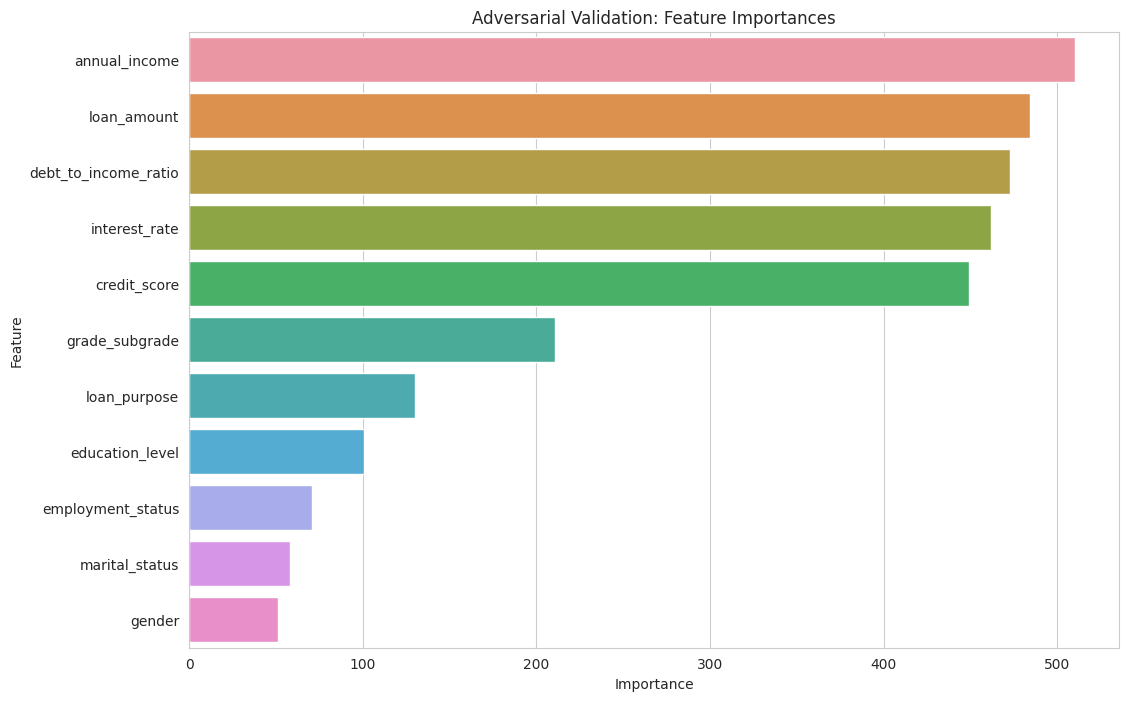

In [16]:
# Analyze Adversarial Model Feature Importances

print("--- Analyzing feature importances of the adversarial model ---")

# Fit the model on the entire adversarial dataset to get the feature importances
adv_model.fit(X_adv, y_adv)

# Create a pandas Series for easy plotting
feature_importances = pd.Series(adv_model.feature_importances_, index=X_adv.columns)

# Sort the importances for a clear visualization
feature_importances = feature_importances.sort_values(ascending=False)

# --- Verification & Plotting ---
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Adversarial Validation: Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# --- Interpretation ---
# Since our AUC was ~0.50, we expect all of these importances to be very low
# and close to each other.
# If one feature had a dramatically higher importance than all others, it would
# be the primary source of the (very minor) drift.
# In our case, we expect this plot to be "flat" and uninteresting, which is
# actually the best possible outcome.

# **The Baseline Model Gauntlet**

In [17]:
# Define the Baseline Models (Truly Quiet Version)

print("--- Defining the dictionary of stable, GPU-native models ---")

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# This version uses the 'verbosity' parameter for LightGBM for guaranteed silence.
baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1),
    "Gaussian Naive Bayes": GaussianNB(),
    "XGBoost RF (GPU)": XGBClassifier(
        n_estimators=100, learning_rate=1, subsample=0.8, colsample_bytree=0.8,
        device='gpu', random_state=RANDOM_SEED
    ),
    "XGBoost (Boosted)": XGBClassifier(random_state=RANDOM_SEED, device='gpu'),
    "LightGBM": LGBMClassifier(
        random_state=RANDOM_SEED, 
        device='gpu', 
        verbosity=-1  # <-- THIS IS THE CORRECT PARAMETER. Replaces verbose=-1.
    ),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_SEED, verbose=0, task_type='GPU')
}

print(f"✅ {len(baseline_models)} truly quiet models have been defined.")
print(list(baseline_models.keys()))


--- Defining the dictionary of stable, GPU-native models ---
✅ 6 truly quiet models have been defined.
['Logistic Regression', 'Gaussian Naive Bayes', 'XGBoost RF (GPU)', 'XGBoost (Boosted)', 'LightGBM', 'CatBoost']


In [18]:
# Create Preprocessing Pipelines

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("--- Creating preprocessing pipelines for sparse and dense data ---")

# Define the transformers
numerical_transformer = StandardScaler()
categorical_transformer_sparse = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
categorical_transformer_dense = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 1. Create the standard SPARSE preprocessor for models that can handle it
preprocessor_sparse = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer_sparse, categorical_features)
    ],
    remainder='passthrough'
)

# 2. Create the DENSE preprocessor for models that require it
preprocessor_dense = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer_dense, categorical_features)
    ],
    remainder='passthrough'
)

print("✅ Two preprocessing pipelines created: 'preprocessor_sparse' and 'preprocessor_dense'.")

--- Creating preprocessing pipelines for sparse and dense data ---
✅ Two preprocessing pipelines created: 'preprocessor_sparse' and 'preprocessor_dense'.


In [19]:
# Define Feature Matrix (X) and Target Vector (y)


print("--- Defining Feature Matrix (X) and Target Vector (y) ---")

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f"✅ Feature Matrix X created with shape: {X.shape}")
print(f"✅ Target Vector y created with shape: {y.shape}")


--- Defining Feature Matrix (X) and Target Vector (y) ---
✅ Feature Matrix X created with shape: (593994, 11)
✅ Target Vector y created with shape: (593994,)


In [20]:
# Run the Stable Baseline Model Gauntlet (Truly Quiet Version)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import time
import warnings

# --- SUPPRESS ALL WARNINGS FOR CLEANER OUTPUT ---
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning) # <-- ADD THIS LINE

print("--- Running the Stable Baseline Model Gauntlet (Quiet Mode) ---")
print(f"Scoring Metric: roc_auc")
print(f"Cross-Validation Strategy: {CV_STRATEGY.__class__.__name__} (n_splits={CV_STRATEGY.get_n_splits()}, n_repeats={CV_STRATEGY.n_repeats})")
print("\nThis will take several minutes...")

baseline_results = {}
models_requiring_dense = ["Gaussian Naive Bayes", "XGBoost RF (GPU)"]
models_using_gpu = ["XGBoost RF (GPU)", "XGBoost (Boosted)", "LightGBM", "CatBoost"]

for model_name, model in baseline_models.items():
    start_time = time.time()
    
    if model_name in models_requiring_dense:
        active_preprocessor = preprocessor_dense
    else:
        active_preprocessor = preprocessor_sparse
        
    if model_name in models_using_gpu:
        n_jobs_for_model = 1
        print(f"  - Running {model_name} on GPU (n_jobs=1 to conserve memory)...")
    else:
        n_jobs_for_model = -1
        print(f"  - Running {model_name} on CPU (n_jobs=-1)...")

    pipeline = Pipeline(steps=[('preprocessor', active_preprocessor), ('classifier', model)])
    
    scores = cross_val_score(pipeline, X, y, 
                             cv=CV_STRATEGY, 
                             scoring='roc_auc', 
                             n_jobs=n_jobs_for_model)
    
    end_time = time.time()
    baseline_results[model_name] = scores
    print(f"  - {model_name}: Mean AUC = {np.mean(scores):.4f} | Std Dev = {np.std(scores):.4f} | Time = {end_time - start_time:.2f}s")

print("\n--- Gauntlet Complete ---")
print("✅ Baseline results have been computed.")

# --- RESTORE WARNINGS (Good Practice) ---
warnings.resetwarnings()


--- Running the Stable Baseline Model Gauntlet (Quiet Mode) ---
Scoring Metric: roc_auc
Cross-Validation Strategy: RepeatedStratifiedKFold (n_splits=15, n_repeats=3)

This will take several minutes...
  - Running Logistic Regression on CPU (n_jobs=-1)...
  - Logistic Regression: Mean AUC = 0.9106 | Std Dev = 0.0010 | Time = 32.81s
  - Running Gaussian Naive Bayes on CPU (n_jobs=-1)...
  - Gaussian Naive Bayes: Mean AUC = 0.8707 | Std Dev = 0.0015 | Time = 15.02s
  - Running XGBoost RF (GPU) on GPU (n_jobs=1 to conserve memory)...
  - XGBoost RF (GPU): Mean AUC = 0.9084 | Std Dev = 0.0009 | Time = 44.70s
  - Running XGBoost (Boosted) on GPU (n_jobs=1 to conserve memory)...
  - XGBoost (Boosted): Mean AUC = 0.9204 | Std Dev = 0.0009 | Time = 28.38s
  - Running LightGBM on GPU (n_jobs=1 to conserve memory)...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  - LightGBM: Mean AUC = 0.9196 | Std Dev = 0.0009 | Time = 60.37s
  - Running CatBoost on GPU (n_jobs=1 to conserve memory)...
  - CatBoost: Mean AUC = 0.9172 | Std Dev = 0.0009 | Time = 143.64s

--- Gauntlet Complete ---
✅ Baseline results have been computed.


In [21]:
# Display and Analyze Results

import pandas as pd
import numpy as np

print("--- Baseline Model Performance (Sorted by Mean AUC) ---")

# Convert the results dictionary to a pandas DataFrame for analysis
results_df = pd.DataFrame(baseline_results).T
results_df['Mean AUC'] = results_df.apply(np.mean, axis=1)
results_df['Std Dev'] = results_df.apply(np.std, axis=1)

# Create a clean summary table
sorted_results_df = results_df[['Mean AUC', 'Std Dev']].sort_values(by='Mean AUC', ascending=False)

# Display the final ranked table
display(sorted_results_df)

--- Baseline Model Performance (Sorted by Mean AUC) ---


,Mean AUC,Std Dev
XGBoost (Boosted),0.920360,0.000853
LightGBM,0.919580,0.000832
CatBoost,0.917231,0.000884
Logistic Regression,0.910552,0.000938
XGBoost RF (GPU),0.908372,0.000884
Gaussian Naive Bayes,0.870677,0.001418


# **Submission Pipeline**

In [22]:
# Train Best Single Model and Generate Submission File (Corrected)
import pandas as pd
import warnings

# Suppress the DeprecationWarnings for a clean run
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("--- Submission Pipeline: Best Single Model ---")

# 1. Define the best model
best_model_name = sorted_results_df.index[0]
best_model = baseline_models[best_model_name]
print(f"✅ Best performing model is: {best_model_name}")

# 2. Create the final training pipeline
print("Creating final training pipeline with the DENSE preprocessor...")
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor_dense),
                                 ('classifier', best_model)])

# 3. Train the pipeline on 100% of the training data
print("Training the final model on 100% of the training data...")
final_pipeline.fit(X, y)
print("✅ Final model trained successfully.")

# 4. Make predictions on the test set
print("Making predictions on the test data...")
test_predictions_proba = final_pipeline.predict_proba(test_df)[:, 1]

# 5. Create the submission file
print("Creating submission file...")

# --- THIS IS THE CORRECTED LINE ---
# We access the 'id' from the index of the test_df DataFrame.
submission_df = pd.DataFrame({'id': test_df.index, 'loan_paid_back': test_predictions_proba})

# Save the file in the required format
submission_df.to_csv('submission_best_single_model.csv', index=False)

print("\n✅ Submission file 'submission_best_single_model.csv' created successfully!")
display(submission_df.head())

# Restore warnings to default
warnings.resetwarnings()


--- Submission Pipeline: Best Single Model ---
✅ Best performing model is: XGBoost (Boosted)
Creating final training pipeline with the DENSE preprocessor...
Training the final model on 100% of the training data...
✅ Final model trained successfully.
Making predictions on the test data...
Creating submission file...

✅ Submission file 'submission_best_single_model.csv' created successfully!


,id,loan_paid_back
0,0,0.941656
1,1,0.983429
2,2,0.386169
3,3,0.916346
4,4,0.964943
